## MDS Lab 4 Program 1

# Name : SAMIM ALI
# Roll No. : 24MDS031
# Student ID : 202404435

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Create a single feature single target dataset using sklearn.datasets.make_regresion

In [2]:
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=200, n_features=1, noise=25, n_targets=1, random_state=42)

# Task 1: Apply Ridge Regression and perform model error analysis on train and test data for different values of lambda.

# 1) Use matplotlib to perform data analysis on the dataset and plot scatter of feature vs target

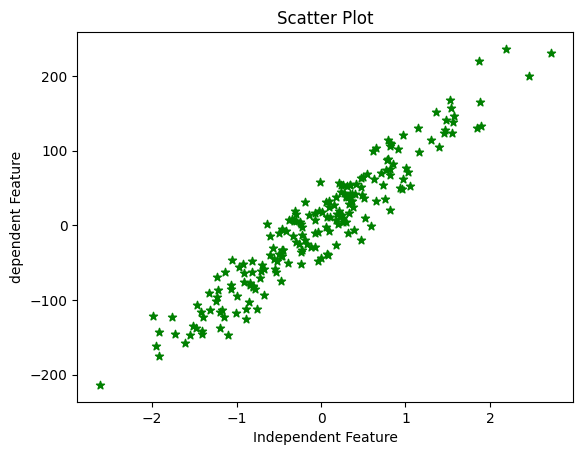

In [3]:
plt.scatter(X,y, c = "green", marker = "*")
plt.xlabel("Independent Feature")
plt.ylabel("dependent Feature")
plt.title("Scatter Plot")
plt.show()

# 2) Normalize the dataset

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160,), (40,))

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = scaler.fit_transform(y_train.reshape(-1, 1))
y_test = scaler.transform(y_test.reshape(-1, 1))

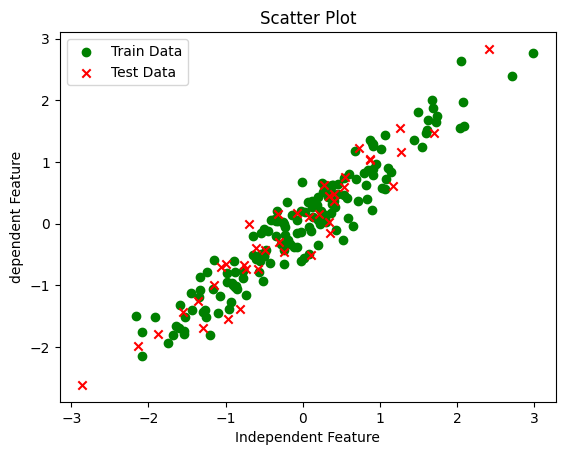

In [6]:
plt.scatter(X_train,y_train, c = "green", label = "Train Data", marker = "o")
plt.scatter(X_test,y_test, c = "red", label = "Test Data", marker = "x")

plt.xlabel("Independent Feature")
plt.ylabel("dependent Feature")
plt.legend()
plt.title("Scatter Plot")
plt.show()

# 3) Develop the loss function according to the Ridge penalty

# 4) Apply gradient descent

In [7]:
theta0 = 100
theta1 = 10
for i in range(100):
  y_pred_train = theta1*X_train + theta0
  dl0 = (-2/len(X_train))*np.sum(y_train - y_pred_train)
  dl1 = (-2/len(X_train))*np.sum((y_train - y_pred_train)*X_train)
  theta0 = theta0 - 0.1*dl0
  theta1 = theta1 - 0.1*dl1

# 5) Calculate the coefficients

In [8]:
theta0, theta1

(2.0370359756285902e-08, 0.9532514439268476)

# 6) Find appropriate value of eta

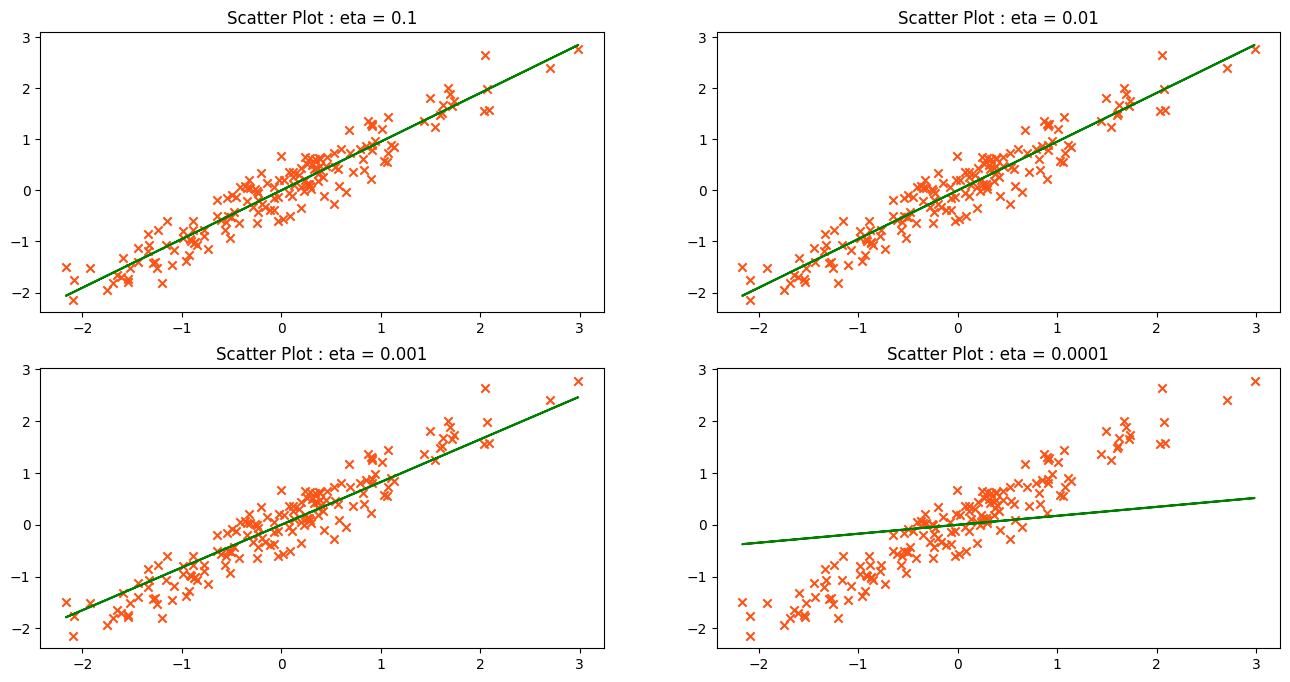

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))


eta = [0.1, 0.01, 0.001, 0.0001]
n = len(X_train)                                # total no. of data points
a = 1
for j, ax in enumerate(axes.flat):
    
    theta0 = 0
    theta1 = 0
    for i in range(1000):                     # iterating 1000 times
        y_pred = theta0 + theta1*X_train            # Calculate predicted value
        dL0 = (-2/n)*np.sum(y_train - y_pred)       # calculate the loss w.r.t theta0
        dL1 = (-2/n)*np.sum((y_train - y_pred)*X_train)   # Calculate the loss w.r.t theta1
        theta0 = theta0 - eta[j]*dL0             # update the theta0 value to minimize the loss
        theta1 = theta1 - eta[j]*dL1             # update the theta1 value to minimize the loss
    ax.scatter(X_train, y_train, color = "#FA5417", marker = "x")
    ax.plot(X_train, theta0 + theta1*X_train, c = 'g')
    ax.set_title(f"Scatter Plot : eta = {eta[j]}")


In [9]:
print(f"Appropriate value of theta is : {0.01}")

Appropriate value of theta is : 0.01


# 7) Analyze the model on various values of lambda

In [10]:
theta0 = 100
theta1 = 10
learning = 0.01
length = len(X_train)
lamda = [0.1, 0.5, 0, 1, 10]
t0 = []
t1 = []
error = []
rs = 0
for k in lamda:
  for i in range(10):
    y_pred_train = theta1*X_train + theta0
    dl0 = (-2/len(X_train))*np.sum(y_train - y_pred_train) + 2*theta0
    dl1 = (-2/len(X_train))*np.sum((y_train - y_pred_train)*X_train) + 2*theta1
    residual = np.sum((-y_train + y_pred_train)**2) + k*(theta1**2)
    # residual = np.sum((-y_train + y_pred_train)**2 + k*(theta1**2))

    theta0 = theta0 - 0.01*dl0
    theta1 = theta1 - 0.01*dl1
  error.append(residual/len(X_train))
  t0.append(theta0)
  t1.append(theta1)

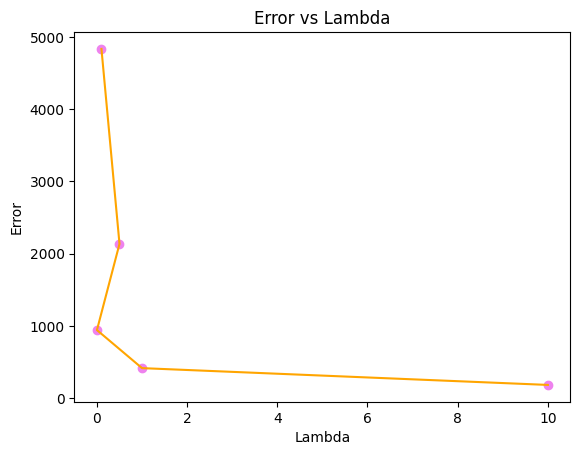

In [11]:
plt.scatter(lamda, error, c = "violet")
plt.plot(lamda, error, c = "orange")
plt.xlabel("Lambda")
plt.ylabel("Error")
plt.title("Error vs Lambda")
plt.show()
